# Reglas de asociación

# Dataset: Recomendación de aromas INHALEX

## Contexto del Dataset

El conjunto de datos **dataset_apriori_transacciones.csv** contiene canastas transaccionales sintéticas de INHALEX. Cada fila representa un pedido y concentra los aromas adquiridos juntos.

Para las reglas de asociación, la columna `tid` identifica cada pedido y la columna `items` contiene los aromas del pedido separados por el carácter `|`. Esta estructura es la entrada directa del algoritmo Apriori.

El dataset está compuesto por **1,661 canastas transaccionales** y contempla **16 aromas** del catálogo sintético.

---

## Descripción de las variables utilizadas

| Variable | Tipo de dato | Descripción |
|----------|--------------|-------------|
| **tid** | Texto | Identificador único de la transacción; corresponde a un pedido. |
| **items** | Texto | Aromas incluidos en el pedido, separados por el carácter `|`. Durante la preparación se convierte en una lista de aromas. |

---

## Información general del dataset

| Característica | Valor |
|----------------|-------|
| Número de registros | 1,661 canastas |
| Número de variables de origen | 2 |
| Aromas disponibles | 16 |
| Tipo de información | Canastas transaccionales de pedidos INHALEX |
| Unidad principal de análisis | Pedidos de compra |
| Variable principal para analizar productos | items |
| Identificador de transacción | tid |

Los productos ya se encuentran en español, por lo que no se requiere un diccionario de traducción.

In [112]:
from pathlib import Path
import json
import unicodedata
from datetime import datetime, timezone
import pandas as pd
from mlxtend.preprocessing import TransactionEncoder
from mlxtend.frequent_patterns import apriori, association_rules

# Las rutas se localizan desde cualquier subcarpeta del proyecto.
PROJECT_ROOT = Path.cwd().resolve()
while PROJECT_ROOT != PROJECT_ROOT.parent and not (PROJECT_ROOT / "ml").is_dir():
    PROJECT_ROOT = PROJECT_ROOT.parent

DATA_PATH = PROJECT_ROOT / "ml" / "exports" / "dataset_apriori_transacciones.csv"
ARTIFACTS_DIR = PROJECT_ROOT / "ml" / "artifacts"
ARTIFACTS_DIR.mkdir(parents=True, exist_ok=True)

# Umbrales del artefacto analítico completo y de la versión operativa de Flask.
MIN_SUPPORT = 0.008
MIN_CONFIDENCE = 0.10
MIN_LIFT = 1.05
FLASK_MIN_SUPPORT = 0.02
FLASK_MIN_CONFIDENCE = 0.40
FLASK_MIN_LIFT = 1.10
MAX_ITEMSET_SIZE = 5
MAX_ANTECEDENT_SIZE = 4

assert DATA_PATH.exists(), f"No se encontró {DATA_PATH}"

Para el desarrollo se utilizan únicamente los eventos:

`event_type = 'purchase'`

No es recomendable mezclar vistas, búsquedas, favoritos o clics porque sí cambia:

- el significado de cada transacción;
- el número total de canastas;
- los valores de soporte;
- las reglas obtenidas;
- la interpretación comercial de los productos comprados juntos.

El soporte mínimo de 0.02 se calcula sobre los pedidos de compra válidos, no sobre todas las interacciones del archivo.

In [113]:
data = pd.read_csv(DATA_PATH, dtype={"tid": "string", "items": "string"})
data.head()

,interaction_id,customer_key,session_id,product_id,product_name,event_type,interaction_strength,occurred_at,channel,order_id,...,quantity,review_rating,review_sentiment,review_text,category,aromas,benefits,content_text,generation_run_id,is_synthetic
0,SYN-INT-0000001,SYN-CUST-0080,SYN-SES-DISC-SYN-CUST-0080-20250103-875680,SYN-PROD-011,Café,view,1.0,2025-01-03T14:12:14-06:00,web_public,NaN,...,NaN,NaN,NaN,NaN,linea-estimulante,cafe|tostado|intenso|estimulante,Perfil tostado e intenso|Sensación energica|Ac...,Café linea-estimulante Inhalador aromático per...,inhalex-synthetic-v1,True
1,SYN-INT-0000002,SYN-CUST-0080,SYN-SES-DISC-SYN-CUST-0080-20250103-675998,SYN-PROD-004,Anís Estrella,view,1.0,2025-01-03T15:41:04-06:00,web_public,NaN,...,NaN,NaN,NaN,NaN,linea-ansiedad-estres,anis|especiado|dulce|estrella,Perfil dulce y especiado|Sensación cálida|Acom...,Anís Estrella linea-ansiedad-estres Inhalador ...,inhalex-synthetic-v1,True
2,SYN-INT-0000003,SYN-CUST-0080,SYN-SES-DISC-SYN-CUST-0080-20250103-997991,SYN-PROD-009,Canela,view,1.0,2025-01-03T15:57:42-06:00,web_public,NaN,...,NaN,NaN,NaN,NaN,linea-resfriado,canela|especiado|cálido|dulce,Sensación cálida|Perfil dulce y especiado|Acom...,Canela linea-resfriado Inhalador aromático per...,inhalex-synthetic-v1,True
3,SYN-INT-0000004,SYN-CUST-0080,SYN-SES-DISC-SYN-CUST-0080-20250103-868847,SYN-PROD-011,Café,view,1.0,2025-01-03T18:36:34-06:00,web_public,NaN,...,NaN,NaN,NaN,NaN,linea-estimulante,cafe|tostado|intenso|estimulante,Perfil tostado e intenso|Sensación energica|Ac...,Café linea-estimulante Inhalador aromático per...,inhalex-synthetic-v1,True
4,SYN-INT-0000005,SYN-CUST-0080,SYN-SES-DISC-SYN-CUST-0080-20250105-955109,SYN-PROD-011,Café,view,1.0,2025-01-05T11:50:21-06:00,web_public,NaN,...,NaN,NaN,NaN,NaN,linea-estimulante,cafe|tostado|intenso|estimulante,Perfil tostado e intenso|Sensación energica|Ac...,Café linea-estimulante Inhalador aromático per...,inhalex-synthetic-v1,True


In [114]:
# Dimensiones del conjunto de datos
data.shape

(26877, 21)

In [115]:
# Limpieza mínima del dataset transaccional final.
transaction_frame = data.dropna(subset=["tid", "items"]).copy()
transaction_frame["tid"] = transaction_frame["tid"].astype(str).str.strip()
transaction_frame["items"] = transaction_frame["items"].astype(str).str.strip()
transaction_frame = transaction_frame[(transaction_frame["tid"] != "") & (transaction_frame["items"] != "")].copy()
transaction_frame["items"] = transaction_frame["items"].str.split("|", regex=False).apply(
    lambda values: list(dict.fromkeys(item.strip() for item in values if item.strip()))
)
transaction_frame = transaction_frame[transaction_frame["items"].str.len() > 0].reset_index(drop=True)
transaction_frame["basket_size"] = transaction_frame["items"].str.len()
assert transaction_frame["tid"].is_unique, "Cada pedido debe representar una sola canasta"
transaction_frame[["tid", "items", "basket_size"]].head()

Líneas válidas: 3,734
Pedidos válidos: 1,661
Productos diferentes: 16


In [116]:
# El archivo ya contiene una canasta completa por pedido.
transactions = transaction_frame["items"].tolist()

# Vista documental: cada fila equivale a una canasta/pedido completo.
transaction_preview = transaction_frame[["tid", "items", "basket_size"]].head()
transaction_preview

Cantidad de listas de transacciones: 1,661


,tid,ordered_at,items,basket_size
0,SYN-ORD-000001,2025-01-08 18:27:37-06:00,[Bugambilia],1
1,SYN-ORD-000002,2025-01-19 13:36:30-06:00,"[Canela, Jengibre, Anís Estrella, Café, Copal]",5
2,SYN-ORD-000004,2025-02-01 10:15:16-06:00,"[Lavanda, Manzanilla]",2
3,SYN-ORD-000005,2025-02-07 16:58:12-06:00,"[Lavanda, Manzanilla, Toronjil, Rosas de Casti...",5
4,SYN-ORD-000006,2025-02-12 17:45:03-06:00,[Lavanda],1


Los nombres de los productos ya están en español. Por ello se utilizan directamente `Toronjil`, `Lavanda`, `Café`, `Canela` y los demás aromas, sin crear copias traducidas de las transacciones ni de las reglas.

In [117]:
# Crear un DataFrame con todas las transacciones
te = TransactionEncoder()
te_ary = te.fit(transactions).transform(transactions)
df = pd.DataFrame(te_ary, columns=te.columns_)

# Visualización de las primeras filas
print(f"Matriz: {df.shape[0]:,} pedidos × {df.shape[1]:,} productos")
df.head()

Matriz: 1,661 pedidos × 16 productos


,Anís Estrella,Bugambilia,Café,Canela,Copal,Eucalipto,Hierbabuena,Jengibre,Lavanda,Manzanilla,Menta,Mirra y Azafrán,Romero,Rosas de Castilla,Toronjil,Vaporub
0,False,True,False,False,False,False,False,False,False,False,False,False,False,False,False,False
1,True,False,True,True,True,False,False,True,False,False,False,False,False,False,False,False
2,False,False,False,False,False,False,False,False,True,True,False,False,False,False,False,False
3,True,False,False,False,False,False,False,False,True,True,False,False,False,True,True,False
4,False,False,False,False,False,False,False,False,True,False,False,False,False,False,False,False


## Métricas de las reglas de asociación

- **Soporte:** proporción de pedidos que contienen el conjunto.
- **Confianza:** probabilidad de comprar el consecuente cuando se compra el antecedente.
- **Lift:** fuerza frente a compras independientes. Un valor mayor que 1 indica asociación positiva.

Para cada métrica se muestran las 20 mejores reglas, ordenadas de mayor a menor. Después de cada tabla se interpretan sus primeras 5 reglas y se propone un posible uso dentro del sistema.

In [118]:
# Generar conjuntos frecuentes y reglas de asociación.
frequent_itemsets = apriori(
    df,
    min_support=MIN_SUPPORT,
    use_colnames=True,
    max_len=MAX_ITEMSET_SIZE,
    low_memory=True
)
rules = association_rules(
    frequent_itemsets,
    metric="confidence",
    min_threshold=MIN_CONFIDENCE,
    num_itemsets=len(df)
)

# Sólo se conservan reglas recomendables: un consecuente y de uno a cuatro antecedentes.
rules = rules[
    rules["support"].ge(MIN_SUPPORT)
    & rules["confidence"].ge(MIN_CONFIDENCE)
    & rules["lift"].ge(MIN_LIFT)
    & rules["consequents"].apply(len).eq(1)
    & rules["antecedents"].apply(len).between(1, MAX_ANTECEDENT_SIZE)
].copy()
rules["cooccurrenceCount"] = (rules["support"] * len(transactions)).round().astype(int)
rules["score"] = rules["confidence"] * rules["lift"]

rules_flask = rules[
    rules["support"].ge(FLASK_MIN_SUPPORT)
    & rules["confidence"].ge(FLASK_MIN_CONFIDENCE)
    & rules["lift"].ge(FLASK_MIN_LIFT)
].copy()
# Alias conservado para las tablas explicativas de la libreta.
rules_flask["puntaje_general"] = rules_flask["score"]

assert not rules.empty, "No se obtuvieron reglas analíticas con los umbrales configurados."
assert not rules_flask.empty, "No se obtuvieron reglas operativas para Flask."

print(f"Conjuntos frecuentes: {len(frequent_itemsets):,}")
print(f"Reglas analíticas: {len(rules):,}")
print(f"Reglas operativas para Flask: {len(rules_flask):,}")

Conjuntos frecuentes: 134
Reglas analíticas: 231
Reglas operativas para Flask: 196


### Relación entre soporte, confianza y lift

Cada punto representa una regla operativa. El color y el tamaño reflejan el valor de lift.

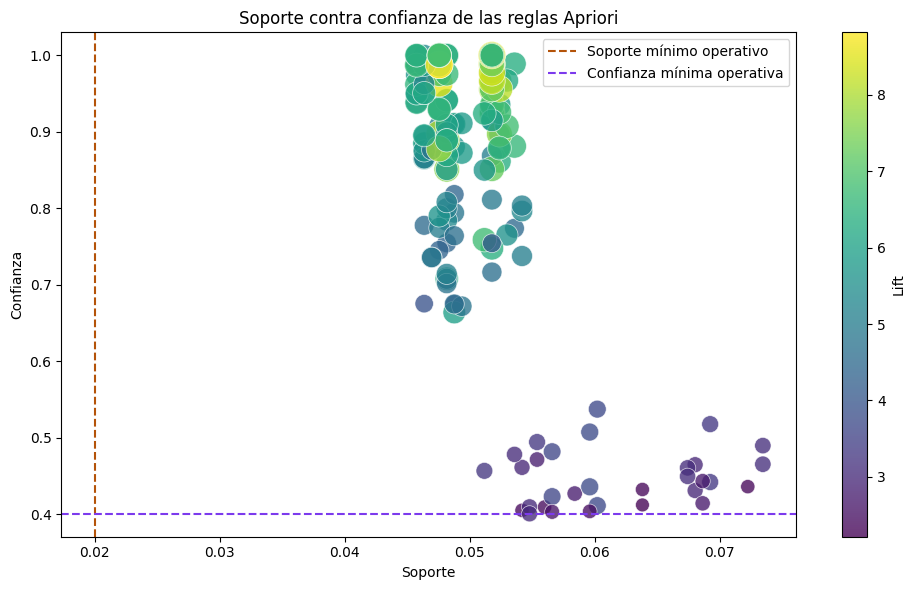

In [119]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 6))
puntos = plt.scatter(
    rules_flask['support'],
    rules_flask['confidence'],
    c=rules_flask['lift'],
    s=rules_flask['lift'] * 45,
    cmap='viridis',
    alpha=0.78,
    edgecolors='white',
    linewidths=0.5
)
plt.axvline(FLASK_MIN_SUPPORT, color='#b45309', linestyle='--', label='Soporte mínimo operativo')
plt.axhline(FLASK_MIN_CONFIDENCE, color='#7c3aed', linestyle='--', label='Confianza mínima operativa')
plt.colorbar(puntos, label='Lift')
plt.title('Soporte contra confianza de las reglas Apriori')
plt.xlabel('Soporte')
plt.ylabel('Confianza')
plt.legend()
plt.tight_layout()
plt.show()

In [120]:
# Los productos ya están en español; sólo se convierten los itemsets a texto.
def itemset_a_texto(itemset):
    return ", ".join(sorted(itemset))

def crear_slug(texto):
    texto = unicodedata.normalize("NFKD", str(texto)).encode("ascii", "ignore").decode("ascii")
    return "-".join("".join(caracter if caracter.isalnum() else " " for caracter in texto.lower()).split())

product_catalog = pd.DataFrame({"slug": sorted(df.columns)})
product_catalog["product_id"] = product_catalog["slug"]
nombres_visibles = {
    "anis-estrella": "Anís Estrella",
    "cafe": "Café",
    "mirra-y-azafran": "Mirra y Azafrán",
    "rosas-de-castilla": "Rosas de Castilla",
}
product_catalog["product_name"] = product_catalog["slug"].map(nombres_visibles).fillna(
    product_catalog["slug"].str.replace("-", " ", regex=False).str.title()
)
product_catalog = product_catalog[["product_id", "product_name", "slug"]]

assert product_catalog["product_id"].is_unique
assert product_catalog["product_name"].is_unique
assert product_catalog["slug"].is_unique

name_to_slug = dict(zip(product_catalog["product_name"], product_catalog["slug"]))
slug_to_name = dict(zip(product_catalog["slug"], product_catalog["product_name"]))
# Alias temporales para mantener las celdas explicativas sin cambiar su estructura.
name_to_id = name_to_slug
id_to_name = slug_to_name

product_catalog

,product_id,product_name,slug
0,SYN-PROD-001,Toronjil,toronjil
1,SYN-PROD-002,Mirra y Azafrán,mirra-y-azafran
2,SYN-PROD-003,Copal,copal
3,SYN-PROD-004,Anís Estrella,anis-estrella
4,SYN-PROD-005,Eucalipto,eucalipto
5,SYN-PROD-006,Lavanda,lavanda
6,SYN-PROD-007,Menta,menta
7,SYN-PROD-008,Romero,romero
8,SYN-PROD-009,Canela,canela
9,SYN-PROD-010,Jengibre,jengibre


In [121]:
from IPython.display import display

TOP_REGLAS = 20

def ordenar_reglas(metrica, cantidad=TOP_REGLAS):
    otras = [m for m in ["support", "confidence", "lift"] if m != metrica]
    return (
        rules.sort_values([metrica] + otras, ascending=False)
        .head(cantidad)
        .reset_index(drop=True)
    )

def crear_tabla(reglas_ordenadas, metrica):
    tabla = pd.DataFrame({
        "antecedente": reglas_ordenadas["antecedents"].apply(itemset_a_texto),
        "consecuente": reglas_ordenadas["consequents"].apply(itemset_a_texto),
        metrica: reglas_ordenadas[metrica]
    })
    return tabla.round(3)

def mostrar_tabla(reglas_ordenadas, metrica):
    display(crear_tabla(reglas_ordenadas, metrica))

In [122]:
def elegir_uso(regla, enfoque):
    # El criterio cambia según la métrica que se está priorizando.
    if enfoque == "support":
        if regla["support"] >= 0.08:
            return "promoción"
        if regla["lift"] >= 4:
            return "paquete"
        return "recomendación"

    if enfoque == "confidence":
        if regla["support"] >= 0.06:
            return "promoción"
        if regla["confidence"] >= 0.80:
            return "recomendación"
        if regla["lift"] >= 4:
            return "paquete"
        return "recomendación"

    if enfoque == "lift":
        if regla["confidence"] < 0.60:
            return "promoción"
        if regla["confidence"] >= 0.80:
            return "recomendación"
        return "paquete"

    if regla["support"] >= 0.07:
        return "promoción"
    if regla["confidence"] >= 0.80:
        return "recomendación"
    return "paquete"

In [123]:
def interpretar_regla(regla, numero, enfoque):
    x = itemset_a_texto(regla["antecedents"])
    y = itemset_a_texto(regla["consequents"])

    if enfoque == "support":
        interpretacion = (
            f"esta asociación aparece en {regla['support']:.1%} de los pedidos. "
            f"Entre quienes compran {x}, {regla['confidence']:.1%} también compra {y}; "
            f"el lift de {regla['lift']:.3f} confirma una relación positiva."
        )
    elif enfoque == "confidence":
        interpretacion = (
            f"los clientes que compran {x} también compran {y} en "
            f"{regla['confidence']:.1%} de los casos. La regla cubre "
            f"{regla['support']:.1%} de los pedidos y la relación es positiva."
        )
    elif enfoque == "lift":
        interpretacion = (
            f"la compra de {x} y {y} ocurre {regla['lift']:.3f} veces más de lo "
            f"esperado si fueran compras independientes. La confianza es "
            f"{regla['confidence']:.1%} y alcanza {regla['support']:.1%} de los pedidos."
        )
    else:
        interpretacion = (
            f"la regla combina un soporte de {regla['support']:.1%}, una confianza de "
            f"{regla['confidence']:.1%} y un lift de {regla['lift']:.3f}; por ello "
            "mantiene un equilibrio favorable entre alcance, probabilidad y fuerza."
        )

    uso = elegir_uso(regla, enfoque)
    usos = {
        "recomendación": f"mostrar {y} como recomendación al comprar {x}",
        "paquete": f"crear un paquete con {x} y {y}",
        "promoción": f"ofrecer una promoción cruzada de {y} al comprar {x}"
    }

    print(f"REGLA {numero}: {{{x}}} → {{{y}}}")
    print(f"Soporte: {regla['support']:.3f} ({regla['support']:.1%} de los pedidos)")
    print(f"Confianza: {regla['confidence']:.3f} ({regla['confidence']:.1%})")
    print(f"Lift: {regla['lift']:.3f}")
    print(f"Interpretación: {interpretacion}")
    print(f"Uso posible ({uso}): {usos[uso]}.")
    print("-" * 100)

def interpretar_primeras_cinco(reglas_ordenadas, enfoque):
    print("Interpretación de las primeras 5 reglas")
    for numero, (_, regla) in enumerate(
        reglas_ordenadas.head(5).iterrows(),
        start=1
    ):
        interpretar_regla(regla, numero, enfoque)

In [124]:
print("MÉTRICA: SOPORTE")
top_soporte = ordenar_reglas("support")
mostrar_tabla(top_soporte, "support")
interpretar_primeras_cinco(top_soporte, "support")

MÉTRICA: SOPORTE


,antecedente,consecuente,support
0,Vaporub,Eucalipto,0.073
1,Eucalipto,Vaporub,0.073
2,Lavanda,Manzanilla,0.072
3,Manzanilla,Lavanda,0.072
4,Jengibre,Canela,0.069
5,Canela,Jengibre,0.069
6,Toronjil,Lavanda,0.069
7,Lavanda,Toronjil,0.069
8,Menta,Eucalipto,0.068
9,Eucalipto,Menta,0.068


Interpretación de las primeras 5 reglas
REGLA 1: {Vaporub} → {Eucalipto}
Soporte: 0.073 (7.3% de los pedidos)
Confianza: 0.490 (49.0%)
Lift: 3.106
Interpretación: esta asociación aparece en 7.3% de los pedidos. Entre quienes compran Vaporub, 49.0% también compra Eucalipto; el lift de 3.106 confirma una relación positiva.
Uso posible (recomendación): mostrar Eucalipto como recomendación al comprar Vaporub.
----------------------------------------------------------------------------------------------------
REGLA 2: {Eucalipto} → {Vaporub}
Soporte: 0.073 (7.3% de los pedidos)
Confianza: 0.466 (46.6%)
Lift: 3.106
Interpretación: esta asociación aparece en 7.3% de los pedidos. Entre quienes compran Eucalipto, 46.6% también compra Vaporub; el lift de 3.106 confirma una relación positiva.
Uso posible (recomendación): mostrar Vaporub como recomendación al comprar Eucalipto.
----------------------------------------------------------------------------------------------------
REGLA 3: {Lavanda} →

### Confianza

Las reglas se ordenan por confianza de mayor a menor. La interpretación considera sus primeras 5 posiciones.

In [125]:
print("MÉTRICA: CONFIANZA")
top_confianza = ordenar_reglas("confidence")
mostrar_tabla(top_confianza, "confidence")
interpretar_primeras_cinco(top_confianza, "confidence")

MÉTRICA: CONFIANZA


,antecedente,consecuente,confidence
0,"Anís Estrella, Café, Jengibre",Copal,1.0
1,"Anís Estrella, Café, Canela, Jengibre",Copal,1.0
2,"Anís Estrella, Café, Copal",Jengibre,1.0
3,"Anís Estrella, Canela, Copal",Jengibre,1.0
4,"Anís Estrella, Café, Canela, Copal",Jengibre,1.0
5,"Anís Estrella, Canela, Copal",Café,1.0
6,"Anís Estrella, Copal, Jengibre",Café,1.0
7,"Canela, Copal, Jengibre",Café,1.0
8,"Anís Estrella, Canela, Copal, Jengibre",Café,1.0
9,"Anís Estrella, Café, Copal",Canela,1.0


Interpretación de las primeras 5 reglas
REGLA 1: {Anís Estrella, Café, Jengibre} → {Copal}
Soporte: 0.052 (5.2% de los pedidos)
Confianza: 1.000 (100.0%)
Lift: 8.518
Interpretación: los clientes que compran Anís Estrella, Café, Jengibre también compran Copal en 100.0% de los casos. La regla cubre 5.2% de los pedidos y la relación es positiva.
Uso posible (recomendación): mostrar Copal como recomendación al comprar Anís Estrella, Café, Jengibre.
----------------------------------------------------------------------------------------------------
REGLA 2: {Anís Estrella, Café, Canela, Jengibre} → {Copal}
Soporte: 0.052 (5.2% de los pedidos)
Confianza: 1.000 (100.0%)
Lift: 8.518
Interpretación: los clientes que compran Anís Estrella, Café, Canela, Jengibre también compran Copal en 100.0% de los casos. La regla cubre 5.2% de los pedidos y la relación es positiva.
Uso posible (recomendación): mostrar Copal como recomendación al comprar Anís Estrella, Café, Canela, Jengibre.
-----------------

### Lift

Las reglas se ordenan por lift de mayor a menor. La interpretación considera sus primeras 5 posiciones.

In [126]:
print("MÉTRICA: LIFT")
top_lift = ordenar_reglas("lift")
mostrar_tabla(top_lift, "lift")
interpretar_primeras_cinco(top_lift, "lift")

MÉTRICA: LIFT


,antecedente,consecuente,lift
0,"Eucalipto, Menta, Romero",Hierbabuena,8.818
1,"Menta, Romero, Vaporub",Hierbabuena,8.818
2,"Eucalipto, Menta, Romero, Vaporub",Hierbabuena,8.818
3,"Eucalipto, Romero, Vaporub",Hierbabuena,8.603
4,"Anís Estrella, Café, Jengibre",Copal,8.518
5,"Anís Estrella, Café, Canela, Jengibre",Copal,8.518
6,"Anís Estrella, Café, Canela",Copal,8.420
7,"Café, Canela, Jengibre",Copal,8.324
8,"Anís Estrella, Canela, Jengibre",Copal,8.231
9,"Café, Jengibre",Copal,8.144


Interpretación de las primeras 5 reglas
REGLA 1: {Eucalipto, Menta, Romero} → {Hierbabuena}
Soporte: 0.048 (4.8% de los pedidos)
Confianza: 0.988 (98.8%)
Lift: 8.818
Interpretación: la compra de Eucalipto, Menta, Romero y Hierbabuena ocurre 8.818 veces más de lo esperado si fueran compras independientes. La confianza es 98.8% y alcanza 4.8% de los pedidos.
Uso posible (recomendación): mostrar Hierbabuena como recomendación al comprar Eucalipto, Menta, Romero.
----------------------------------------------------------------------------------------------------
REGLA 2: {Menta, Romero, Vaporub} → {Hierbabuena}
Soporte: 0.048 (4.8% de los pedidos)
Confianza: 0.988 (98.8%)
Lift: 8.818
Interpretación: la compra de Menta, Romero, Vaporub y Hierbabuena ocurre 8.818 veces más de lo esperado si fueran compras independientes. La confianza es 98.8% y alcanza 4.8% de los pedidos.
Uso posible (recomendación): mostrar Hierbabuena como recomendación al comprar Menta, Romero, Vaporub.
-----------------

In [127]:
# Puntaje de producción: confianza × lift.
# El soporte se conserva como filtro para evitar reglas poco representativas.
reglas_generales = rules.copy()
reglas_generales["puntaje_general"] = reglas_generales["score"]

top_general = (
    reglas_generales.sort_values("score", ascending=False)
    .head(TOP_REGLAS)
    .reset_index(drop=True)
)

## Mejores reglas de manera general

Para combinar las tres métricas sin favorecer sus distintas escalas, cada una se divide entre su valor máximo y después se calcula el promedio. La tabla se ordena por ese puntaje general, pero muestra únicamente los valores originales de soporte, confianza y lift.

In [128]:
def crear_tabla_general(reglas_ordenadas):
    tabla = pd.DataFrame({
        "antecedente": reglas_ordenadas["antecedents"].apply(itemset_a_texto),
        "consecuente": reglas_ordenadas["consequents"].apply(itemset_a_texto),
        "support": reglas_ordenadas["support"],
        "confidence": reglas_ordenadas["confidence"],
        "lift": reglas_ordenadas["lift"]
    })
    return tabla.round(3)

print("MEJORES REGLAS SEGÚN LAS TRES MÉTRICAS")
display(crear_tabla_general(top_general))
interpretar_primeras_cinco(top_general, "general")

MEJORES REGLAS SEGÚN LAS TRES MÉTRICAS


,antecedente,consecuente,support,confidence,lift
0,"Eucalipto, Menta, Romero",Hierbabuena,0.048,0.988,8.818
1,"Eucalipto, Menta, Romero, Vaporub",Hierbabuena,0.048,0.988,8.818
2,"Menta, Romero, Vaporub",Hierbabuena,0.048,0.988,8.818
3,"Anís Estrella, Café, Jengibre",Copal,0.052,1.000,8.518
4,"Anís Estrella, Café, Canela, Jengibre",Copal,0.052,1.000,8.518
5,"Anís Estrella, Café, Canela",Copal,0.052,0.989,8.420
6,"Eucalipto, Romero, Vaporub",Hierbabuena,0.048,0.963,8.603
7,"Café, Canela, Jengibre",Copal,0.052,0.977,8.324
8,"Anís Estrella, Canela, Jengibre",Copal,0.052,0.966,8.231
9,"Café, Jengibre",Copal,0.052,0.956,8.144


Interpretación de las primeras 5 reglas
REGLA 1: {Eucalipto, Menta, Romero} → {Hierbabuena}
Soporte: 0.048 (4.8% de los pedidos)
Confianza: 0.988 (98.8%)
Lift: 8.818
Interpretación: la regla combina un soporte de 4.8%, una confianza de 98.8% y un lift de 8.818; por ello mantiene un equilibrio favorable entre alcance, probabilidad y fuerza.
Uso posible (recomendación): mostrar Hierbabuena como recomendación al comprar Eucalipto, Menta, Romero.
----------------------------------------------------------------------------------------------------
REGLA 2: {Eucalipto, Menta, Romero, Vaporub} → {Hierbabuena}
Soporte: 0.048 (4.8% de los pedidos)
Confianza: 0.988 (98.8%)
Lift: 8.818
Interpretación: la regla combina un soporte de 4.8%, una confianza de 98.8% y un lift de 8.818; por ello mantiene un equilibrio favorable entre alcance, probabilidad y fuerza.
Uso posible (recomendación): mostrar Hierbabuena como recomendación al comprar Eucalipto, Menta, Romero, Vaporub.
---------------------------

## Exportación para Flask

Para el sistema se exportan tres archivos:

- `apriori-rules.csv`: tabla legible para revisar las reglas operativas.
- `apriori-rules.v1.json`: artefacto analítico completo.
- `apriori-rules.flask.v1.json`: artefacto reducido que Flask puede cargar al iniciar.

Los JSON utilizan slugs estables derivados del nombre del aroma (por ejemplo, `mirra-y-azafran`) y conservan el nombre para mostrarlo. Incluyen métricas, umbrales, productos populares de respaldo y el contrato de consulta. Sólo se exportan reglas con un producto consecuente, de modo que cada coincidencia produzca una recomendación individual.

In [129]:
# Preparar reglas operativas con un solo producto consecuente para Flask.
reglas_exportables = rules_flask.sort_values(
    ["score", "lift", "confidence", "support"],
    ascending=False
).reset_index(drop=True)

reglas_csv = pd.DataFrame({
    "antecedent_ids": reglas_exportables["antecedents"].apply(
        lambda values: "|".join(name_to_id[name] for name in sorted(values))
    ),
    "antecedent_names": reglas_exportables["antecedents"].apply(
        lambda values: "|".join(sorted(values))
    ),
    "consequent_id": reglas_exportables["consequents"].apply(
        lambda values: name_to_id[next(iter(values))]
    ),
    "consequent_name": reglas_exportables["consequents"].apply(
        lambda values: next(iter(values))
    ),
    "support": reglas_exportables["support"],
    "confidence": reglas_exportables["confidence"],
    "lift": reglas_exportables["lift"],
    "puntaje_general": reglas_exportables["puntaje_general"]
})

csv_path = ARTIFACTS_DIR / "apriori-rules.csv"
# El CSV se guarda una sola vez al final, con el contrato definitivo.

product_counts = (
    transaction_frame[["tid", "items"]]
    .explode("items")
    .groupby("items")
    .size()
    .rename_axis("product_id")
    .reset_index(name="purchaseCount")
)
product_counts["product_name"] = product_counts["product_id"].map(slug_to_name)
product_counts = product_counts.set_index(["product_id", "product_name"])["purchaseCount"].sort_values(ascending=False)

rules_payload = [
    {
        "antecedentProductIds": row.antecedent_ids.split("|"),
        "antecedentNames": row.antecedent_names.split("|"),
        "consequentProductId": row.consequent_id,
        "consequentName": row.consequent_name,
        "support": round(float(row.support), 6),
        "confidence": round(float(row.confidence), 6),
        "lift": round(float(row.lift), 6),
        "score": round(float(row.puntaje_general), 6)
    }
    for row in reglas_csv.itertuples(index=False)
]

popular_fallbacks = [
    {
        "productId": product_id,
        "name": product_name,
        "transactionCount": int(count),
        "support": round(float(count / len(transactions)), 6)
    }
    for (product_id, product_name), count in product_counts.items()
]

artifact = {
    "schemaVersion": "flask-association-rules.v1",
    "artifactType": "association_rules",
    "model": {
        "name": "Apriori",
        "minSupport": MIN_SUPPORT,
        "minLift": MIN_LIFT,
        "maxItemsetSize": 3,
        "isSynthetic": True
    },
    "training": {
        "transactions": int(len(transactions)),
        "products": int(df.shape[1]),
        "frequentItemsets": int(len(frequent_itemsets)),
        "associationRules": int(len(rules_payload))
    },
    "queryContract": {
        "input": "product_id únicos presentes en la bolsa",
        "match": "antecedentProductIds debe ser subconjunto de la bolsa",
        "exclude": "no recomendar productos ya presentes",
        "ranking": "score, lift, confidence y support de mayor a menor",
        "fallback": "popularFallbacks excluyendo productos ya presentes",
        "topN": 3,
        "postValidation": "Flask debe validar producto activo, disponibilidad y stock"
    },
    "rules": rules_payload,
    "popularFallbacks": popular_fallbacks
}

json_path = ARTIFACTS_DIR / "apriori-rules.flask.v1.json"
# Exportacion final con el contrato que consumiran Flask y el sistema web.
def serializar_reglas(dataframe):
    return [
        {
            "antecedentSlugs": [name_to_slug[name] for name in sorted(row.antecedents)],
            "antecedentNames": sorted(row.antecedents),
            "consequentSlug": name_to_slug[next(iter(row.consequents))],
            "consequentName": next(iter(row.consequents)),
            "support": round(float(row.support), 6),
            "confidence": round(float(row.confidence), 6),
            "lift": round(float(row.lift), 6),
            "cooccurrenceCount": int(row.cooccurrenceCount),
            "score": round(float(row.score), 6)
        }
        for row in dataframe.sort_values(["score", "lift", "confidence", "support"], ascending=False).itertuples(index=False)
    ]

all_rules_payload = serializar_reglas(rules)
flask_rules_payload = serializar_reglas(rules_flask)

popular_by_name = (
    transaction_frame[["tid", "items"]]
    .explode("items")
    .assign(product_name=lambda frame: frame["items"].map(slug_to_name))
    .groupby("product_name")
    .size()
    .sort_values(ascending=False)
)
popular_fallbacks = [
    {
        "slug": name_to_slug[name],
        "name": name,
        "support": round(float(count / len(transactions)), 6),
        "transactionCount": int(count)
    }
    for name, count in popular_by_name.items()
]

def resumen_metricas(dataframe):
    return {
        "rules": int(len(dataframe)),
        "multiAntecedentRules": int(dataframe["antecedents"].apply(len).gt(1).sum()),
        "maxAntecedentSizeFound": int(dataframe["antecedents"].apply(len).max()),
        "catalogCoverage": round(float(len({next(iter(values)) for values in dataframe["consequents"]}) / df.shape[1]), 6)
    }

period_start = None  # El dataset final no conserva una marca temporal por pedido.
period_end = None
generated_at = datetime.now(timezone.utc).isoformat()

canonical_artifact = {
    "schemaVersion": "1.1",
    "model": {
        "name": "Apriori",
        "version": "2.0.0",
        "generatedAt": generated_at,
        "isSynthetic": True
    },
    "training": {
        "transactions": int(len(transactions)),
        "periodStart": period_start,
        "periodEnd": period_end,
        "minSupport": MIN_SUPPORT,
        "minConfidence": MIN_CONFIDENCE,
        "minLift": MIN_LIFT,
        "maxItemsetSize": MAX_ITEMSET_SIZE,
        "maxAntecedentSize": MAX_ANTECEDENT_SIZE
    },
    "metrics": resumen_metricas(rules),
    "rules": all_rules_payload,
    "popularFallbacks": popular_fallbacks
}

flask_artifact = {
    "schemaVersion": "flask-apriori-rules.v1",
    "model": {
        "name": "Apriori",
        "version": "1.0.0",
        "randomSeed": 20260717,
        "isSynthetic": True
    },
    "training": {
        "transactions": int(len(transactions)),
        "periodStart": period_start,
        "periodEnd": period_end,
        "minSupport": FLASK_MIN_SUPPORT,
        "minConfidence": FLASK_MIN_CONFIDENCE,
        "minLift": FLASK_MIN_LIFT,
        "maxItemsetSize": MAX_ITEMSET_SIZE,
        "maxAntecedentSize": MAX_ANTECEDENT_SIZE
    },
    "metrics": resumen_metricas(rules_flask),
    "queryContract": {
        "input": "slugs únicos de productos presentes en la bolsa actual",
        "match": "antecedentSlugs debe ser subconjunto de la bolsa",
        "exclude": "no recomendar aromas ya presentes",
        "postValidation": "producto activo, disponible y con stock suficiente en MongoDB",
        "fallback": "popularFallbacks excluyendo aromas ya presentes",
        "ranking": "agrupar coincidencias por consequentSlug y conservar mayor score, lift, confidence y support",
        "topN": 3,
        "largeBasketPolicy": "en bolsas de cinco o más aromas se aplican todos los antecedentes de uno a cuatro aromas que sean subconjuntos de la bolsa"
    },
    "rules": flask_rules_payload,
    "popularFallbacks": popular_fallbacks
}

reglas_csv = pd.DataFrame({
    "antecedent_slugs": ["|".join(rule["antecedentSlugs"]) for rule in flask_rules_payload],
    "antecedent_names": ["|".join(rule["antecedentNames"]) for rule in flask_rules_payload],
    "consequent_slug": [rule["consequentSlug"] for rule in flask_rules_payload],
    "consequent_name": [rule["consequentName"] for rule in flask_rules_payload],
    "support": [rule["support"] for rule in flask_rules_payload],
    "confidence": [rule["confidence"] for rule in flask_rules_payload],
    "lift": [rule["lift"] for rule in flask_rules_payload],
    "score": [rule["score"] for rule in flask_rules_payload]
})
reglas_csv.to_csv(csv_path, index=False, encoding="utf-8-sig")

canonical_json_path = ARTIFACTS_DIR / "apriori-rules.v1.json"
flask_json_path = ARTIFACTS_DIR / "apriori-rules.flask.v1.json"
canonical_json_path.write_text(json.dumps(canonical_artifact, ensure_ascii=False, indent=2) + "\n", encoding="utf-8")
flask_json_path.write_text(json.dumps(flask_artifact, ensure_ascii=False, indent=2) + "\n", encoding="utf-8")

artifact = flask_artifact
rules_payload = flask_rules_payload
json_path = flask_json_path

print("Archivo CSV:", csv_path.resolve())
print("Archivo JSON:", json_path.resolve())
print("Reglas exportadas:", len(rules_payload))

Archivo CSV: C:\Users\David\Documents\Proyecto-INHALEX\ml\artifacts\apriori-rules.csv
Archivo JSON: C:\Users\David\Documents\Proyecto-INHALEX\ml\artifacts\apriori-rules.flask.v1.json
Reglas exportadas: 196


## Comprobación de la exportación

El JSON se carga nuevamente y se utiliza con una bolsa de ejemplo. Flask deberá aplicar la misma lógica: buscar antecedentes contenidos en la bolsa, excluir productos ya presentes, ordenar las recomendaciones y completar con popularidad cuando no existan suficientes reglas.

In [130]:
loaded_artifact = json.loads(json_path.read_text(encoding="utf-8"))

assert loaded_artifact["schemaVersion"] == "flask-apriori-rules.v1"
assert isinstance(loaded_artifact["rules"], list)
assert loaded_artifact["rules"]
assert all(1 <= len(rule["antecedentSlugs"]) <= MAX_ANTECEDENT_SIZE for rule in loaded_artifact["rules"])
assert all(
    rule["consequentSlug"] not in rule["antecedentSlugs"]
    for rule in loaded_artifact["rules"]
)

def recomendar_productos(artifact, basket_product_ids, top_n=None):
    basket = set(basket_product_ids)
    limit = top_n or artifact["queryContract"]["topN"]

    best_by_product = {}
    for rule in artifact["rules"]:
        antecedent = set(rule["antecedentSlugs"])
        product_id = rule["consequentSlug"]
        if antecedent.issubset(basket) and product_id not in basket:
            previous = best_by_product.get(product_id)
            key = (rule["score"], rule["lift"], rule["confidence"], rule["support"], len(antecedent))
            previous_key = (previous["score"], previous["lift"], previous["confidence"], previous["support"], len(previous["antecedentSlugs"])) if previous else None
            if previous is None or key > previous_key:
                best_by_product[product_id] = rule

    recommendations = [
        {**rule, "origen": "regla Apriori"}
        for rule in sorted(
            best_by_product.values(),
            key=lambda rule: (rule["score"], rule["lift"], rule["confidence"], rule["support"], len(rule["antecedentSlugs"])),
            reverse=True
        )
    ][:limit]
    used_ids = set(best_by_product)
    if len(recommendations) == limit:
        return recommendations

    for fallback in artifact["popularFallbacks"]:
        product_id = fallback["slug"]
        if product_id not in basket and product_id not in used_ids:
            recommendations.append({
                **fallback,
                "consequentSlug": product_id,
                "consequentName": fallback["name"],
                "origen": "popularidad"
            })
            used_ids.add(product_id)
        if len(recommendations) == limit:
            break

    return recommendations

multi_antecedent_rules = [rule for rule in loaded_artifact["rules"] if len(rule["antecedentSlugs"]) >= 3]
best_rule = max(
    multi_antecedent_rules or loaded_artifact["rules"],
    key=lambda rule: (rule["score"], rule["lift"], rule["confidence"], rule["support"])
)
example_basket = best_rule["antecedentSlugs"]
example_recommendations = pd.DataFrame(
    recomendar_productos(loaded_artifact, example_basket)
)

print("Bolsa de ejemplo:", [id_to_name[product_id] for product_id in example_basket])
display(example_recommendations[[
    "consequentName", "origen", "support", "confidence", "lift"
]].head(loaded_artifact["queryContract"]["topN"]))

# Evaluación de retención: 80 % inicial y 20 % final según el orden del dataset.
split_index = max(1, int(len(transaction_frame) * 0.80))
train_transactions = transaction_frame.iloc[:split_index]["items"].tolist()
test_transactions = transaction_frame.iloc[split_index:]["items"].tolist()

te_eval = TransactionEncoder()
train_matrix = pd.DataFrame(
    te_eval.fit(train_transactions).transform(train_transactions),
    columns=te_eval.columns_
)
frequent_itemsets_eval = apriori(
    train_matrix, min_support=FLASK_MIN_SUPPORT, use_colnames=True,
    max_len=MAX_ITEMSET_SIZE, low_memory=True
)
rules_eval = association_rules(
    frequent_itemsets_eval, metric="confidence",
    min_threshold=FLASK_MIN_CONFIDENCE, num_itemsets=len(train_transactions)
)
rules_eval = rules_eval[
    rules_eval["lift"].ge(FLASK_MIN_LIFT)
    & rules_eval["consequents"].apply(len).eq(1)
    & rules_eval["antecedents"].apply(len).between(1, MAX_ANTECEDENT_SIZE)
].copy()
rules_eval["score"] = rules_eval["confidence"] * rules_eval["lift"]
popular_train = pd.Series([item for basket in train_transactions for item in basket]).value_counts().index.tolist()

evaluated_contexts = rule_contexts = rule_hits = baseline_hits = 0
for basket in test_transactions:
    if len(basket) < 2:
        continue
    for hidden in basket:
        context = set(basket) - {hidden}
        evaluated_contexts += 1
        candidates = rules_eval[
            rules_eval["antecedents"].apply(lambda values: set(values).issubset(context))
            & rules_eval["consequents"].apply(lambda values: next(iter(values)) not in context)
        ]
        if not candidates.empty:
            rule_contexts += 1
            selected = candidates.sort_values(["score", "lift", "confidence", "support"], ascending=False).iloc[0]
            rule_hits += int(next(iter(selected["consequents"])) == hidden)
        fallback = next((name for name in popular_train if name not in context), None)
        baseline_hits += int(fallback == hidden)

temporal_metrics = {
    "temporalCoverage": round(rule_contexts / evaluated_contexts, 6) if evaluated_contexts else 0.0,
    "temporalTop1WhenRuleApplies": round(rule_hits / rule_contexts, 6) if rule_contexts else 0.0,
    "temporalTop1EndToEnd": round(rule_hits / evaluated_contexts, 6) if evaluated_contexts else 0.0,
    "popularBaselineTop1": round(baseline_hits / evaluated_contexts, 6) if evaluated_contexts else 0.0,
    "evaluatedContexts": int(evaluated_contexts)
}
loaded_artifact["metrics"].update(temporal_metrics)
json_path.write_text(json.dumps(loaded_artifact, ensure_ascii=False, indent=2) + "\n", encoding="utf-8")

canonical_artifact["metrics"].update({
    "temporalCoverage": temporal_metrics["temporalCoverage"],
    "temporalTop1HitRate": temporal_metrics["temporalTop1EndToEnd"],
    "popularBaselineTop1": temporal_metrics["popularBaselineTop1"],
    "evaluatedContexts": temporal_metrics["evaluatedContexts"]
})
canonical_json_path.write_text(json.dumps(canonical_artifact, ensure_ascii=False, indent=2) + "\n", encoding="utf-8")
pd.Series(temporal_metrics, name="evaluación temporal 80/20")

print("Comprobación terminada: los archivos son recargables y utilizables por Flask.")

Bolsa de ejemplo: ['Eucalipto', 'Menta', 'Romero']


,consequentName,origen,support,confidence,lift
0,Hierbabuena,regla Apriori,0.047562,0.9875,8.818481
1,Vaporub,regla Apriori,0.048164,1.0000,6.670683
2,Manzanilla,popularidad,0.186033,NaN,NaN


Comprobación terminada: los archivos son recargables y utilizables por Flask.
